In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [4]:
# Load the data
data = pd.read_csv('iris_dataset.csv')


In [5]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# Prepare features and target
X = data.drop('target', axis=1)
y = data['target']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

K=1, Accuracy: 0.9667
K=3, Accuracy: 1.0000
K=5, Accuracy: 1.0000
K=7, Accuracy: 1.0000
K=9, Accuracy: 1.0000
K=11, Accuracy: 1.0000
K=15, Accuracy: 1.0000


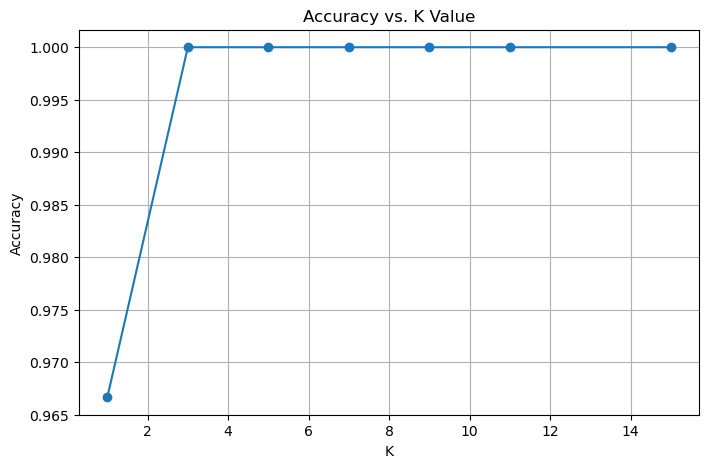

In [7]:
# Experiment with different K values
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k}, Accuracy: {acc:.4f}")

# Plot accuracy vs. K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

Best K=5, Test Accuracy: 1.0000


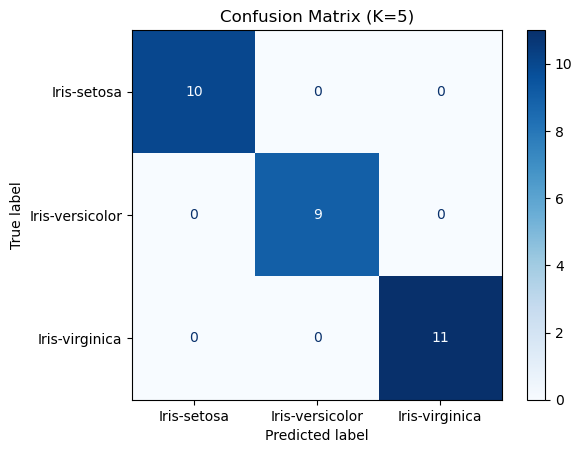

In [8]:
# Train KNN with best K (e.g., K=5)
best_k = 5
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Best K={best_k}, Test Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (K=5)')
plt.show()

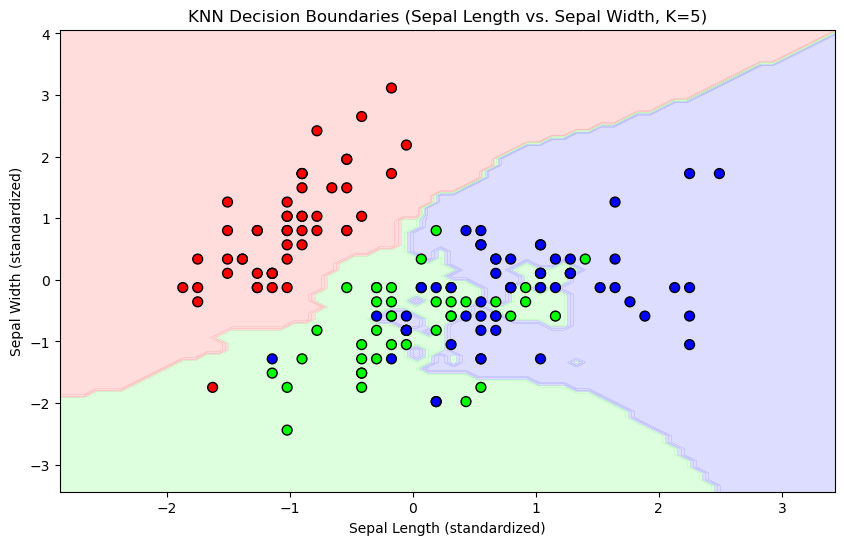

In [9]:
from matplotlib.colors import ListedColormap

# Select two features for visualization
X_2d = X_scaled[:, [0, 1]]  # Sepal length, sepal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

# Train KNN on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d, y_train_2d)

# Create mesh grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on mesh grid
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([knn_2d.classes_.tolist().index(z) for z in Z])  # Convert labels to indices
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['#FF0000', '#00FF00', '#0000FF']
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=[cmap_bold[knn_2d.classes_.tolist().index(label)] for label in y], 
            edgecolor='k', s=50)
plt.title('KNN Decision Boundaries (Sepal Length vs. Sepal Width, K=5)')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.show()